In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from fcapy.context import FormalContext

In [11]:
df = pd.read_csv('books_binary.csv')

TARGET_COLUMN = "is_bestseller"

# Features (exclude id, title, author, target)
feature_cols = [
    'pages_gt_300', 'pages_gt_500', 'year_recent', 'year_classic',
    'genre_fiction', 'genre_nonfiction', 'genre_fantasy', 'genre_mystery',
    'genre_children', 'author_russian', 'is_popular', 'part_of_series'
]

data = pd.read_csv("books_binary.csv")

X = data[feature_cols]
y = data[TARGET_COLUMN]

# ВАЖНО: Строковые индексы для FCA
X.index = X.index.astype(str)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

# Сохраняем строковые индексы после split
X_train.index = X_train.index.astype(str)
X_test.index = X_test.index.astype(str)

print(f"Dataset: {len(data)} books")
print(f"Train: {len(X_train)}, Test: {len(X_test)}")
print(f"Bestsellers: {y.sum()} ({y.sum()/len(y)*100:.1f}%)")



Dataset: 374 books
Train: 280, Test: 94
Bestsellers: 55 (14.7%)


In [14]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier


models = {
    # kNN — требует стандартизации
    "kNN": (
        Pipeline([
            ("scaler", StandardScaler()),
            ("model", KNeighborsClassifier())
        ]),
        {
            "model__n_neighbors": [3, 5, 7],
            "model__weights": ["uniform", "distance"]
        }
    ),

    # Naive Bayes — без стандартизации
    "Naive Bayes": (
        GaussianNB(),
        {
            "var_smoothing": [1e-9, 1e-8, 1e-7]
        }
    ),

    # Logistic Regression — требует стандартизации
    "Logistic Regression": (
        Pipeline([
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(max_iter=2000))
        ]),
        {
            "model__C": [0.1, 1, 10]
        }
    ),

    # SVM — требует стандартизации
    "SVM": (
        Pipeline([
            ("scaler", StandardScaler()),
            ("model", SVC())
        ]),
        {
            "model__C": [0.1, 1, 10],
            "model__kernel": ["linear", "rbf"]
        }
    ),

    # Decision Tree — БЕЗ стандартизации
    "Decision Tree": (
        DecisionTreeClassifier(random_state=42),
        {
            "max_depth": [3, 5, 10],
            "min_samples_split": [2, 5]
        }
    ),

    # Random Forest — БЕЗ стандартизации
    "Random Forest": (
        RandomForestClassifier(random_state=42),
        {
            "n_estimators": [100, 200],
            "max_depth": [5, 10]
        }
    )
}

print(f"Defined {len(models)} models for comparison")


Defined 6 models for comparison


In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, f1_score, classification_report

results = []

for name, (model, params) in models.items():
    print(f"\n{name}")

    try:
        grid = GridSearchCV(
            estimator=model,
            param_grid=params,
            cv=5,
            scoring="f1",
            n_jobs=-1
        )

        grid.fit(X_train, y_train)

        best_model = grid.best_estimator_
        y_pred = best_model.predict(X_test)

        acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)

        results.append([name, acc, f1])

        print("Best parameters:", grid.best_params_)
        print(f"Accuracy: {acc:.3f}")
        print(f"F1-score: {f1:.3f}")
        print("Classification report:")
        print(classification_report(y_test, y_pred))

    except Exception as e:
        print(f"ERROR training {name}: {e}")
        results.append([name, 0, 0])

print(f"\n✓ Trained {len(results)} models")



================ kNN ================
Best parameters: {'model__n_neighbors': 3, 'model__weights': 'distance'}
Accuracy: 0.926
F1-score: 0.720
Classification report:
              precision    recall  f1-score   support

       False       0.94      0.97      0.96        80
        True       0.82      0.64      0.72        14

    accuracy                           0.93        94
   macro avg       0.88      0.81      0.84        94
weighted avg       0.92      0.93      0.92        94


================ Naive Bayes ================
Best parameters: {'var_smoothing': 1e-09}
Accuracy: 0.585
F1-score: 0.361
Classification report:
              precision    recall  f1-score   support

       False       0.94      0.55      0.69        80
        True       0.23      0.79      0.36        14

    accuracy                           0.59        94
   macro avg       0.59      0.67      0.53        94
weighted avg       0.83      0.59      0.64        94


================ Logistic Regressi

In [19]:
# Create results table
results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "F1-score"])

print("BASELINE MODELS COMPARISON")
print(results_df.sort_values(by="F1-score", ascending=False).to_string(index=False))

BASELINE MODELS COMPARISON
              Model  Accuracy  F1-score
Logistic Regression  0.957447  0.857143
                SVM  0.957447  0.857143
      Random Forest  0.946809  0.800000
      Decision Tree  0.936170  0.769231
                kNN  0.925532  0.720000
        Naive Bayes  0.585106  0.360656


In [20]:
from fcapy.context import FormalContext
from fcapy.lattice import ConceptLattice

# Create formal context
K_train = FormalContext.from_pandas(X_train)

# Build concept lattice
L = ConceptLattice.from_context(K_train, algo='Sofia', is_monotone=True)

print(f"Concept lattice: {len(L)} concepts")

Concept lattice: 91 concepts


In [27]:
# Calculate F1-score for each concept
for c in L:
    y_preds = np.zeros(K_train.n_objects)
    y_preds[list(c.extent_i)] = 1
    c.measures['f1_score'] = f1_score(y_train, y_preds)

# Extract F1-scores into array
f1_scores = np.array([c.measures['f1_score'] for c in L])

# Select top-10 concepts
best_concepts = list(f1_scores.argsort()[::-1][:10])

print("Best concepts selected:", best_concepts)
print(f"Best F1-score: {f1_scores[best_concepts[0]]:.3f}")


Best concepts selected: [np.int64(15), np.int64(9), np.int64(20), np.int64(21), np.int64(13), np.int64(14), np.int64(26), np.int64(30), np.int64(18), np.int64(19)]
Best F1-score: 0.766


In [28]:
print("Best concepts indices:", best_concepts)
print("\nTop-5 concepts F1-scores:")
for i, idx in enumerate(best_concepts[:5]):
    concept = L[idx][0]  # Берем первый элемент кортежа!
    print(f"  {i+1}. Concept {idx}: F1={concept.measures['f1_score']:.3f}")
    print(f"      Intent: {concept.intent}")


Best concepts indices: [np.int64(15), np.int64(9), np.int64(20), np.int64(21), np.int64(13), np.int64(14), np.int64(26), np.int64(30), np.int64(18), np.int64(19)]

Top-5 concepts F1-scores:
  1. Concept 15: F1=0.766
      Intent: ('year_classic', 'author_russian', 'part_of_series')
  2. Concept 9: F1=0.750
      Intent: ('year_classic', 'author_russian')
  3. Concept 20: F1=0.683
      Intent: ('year_classic', 'genre_fantasy', 'author_russian', 'part_of_series')
  4. Concept 21: F1=0.672
      Intent: ('year_classic', 'genre_children', 'author_russian', 'part_of_series')
  5. Concept 13: F1=0.653
      Intent: ('year_classic', 'genre_fantasy', 'author_russian')


In [31]:
# Проверка данных
print("y_train unique values:", y_train.unique())
print("y_train value counts:")
print(y_train.value_counts())

print("\nX_train shape:", X_train.shape)
print("X_train dtypes:")
print(X_train.dtypes)

print("\nSample X_train:")
print(X_train.head())


y_train unique values: [False  True]
y_train value counts:
is_bestseller
False    239
True      41
Name: count, dtype: int64

X_train shape: (280, 12)
X_train dtypes:
pages_gt_300        bool
pages_gt_500        bool
year_recent         bool
year_classic        bool
genre_fiction       bool
genre_nonfiction    bool
genre_fantasy       bool
genre_mystery       bool
genre_children      bool
author_russian      bool
is_popular          bool
part_of_series      bool
dtype: object

Sample X_train:
     pages_gt_300  pages_gt_500  year_recent  year_classic  genre_fiction  \
306          True          True        False         False          False   
60           True          True        False          True          False   
348          True         False         True         False          False   
82          False         False         True         False          False   
359          True         False         True         False          False   

     genre_nonfiction  genre_fantasy  g

In [32]:
import neural_lib58 as nl

# Конвертируем y_train в int для Neural FCA
y_train_int = y_train.astype(int)
y_test_int = y_test.astype(int)

# Create network (targets должны быть int)
cn = nl.ConceptNetwork.from_lattice(L, best_concepts, [0, 1])

# Train
f1_list_test = []
f1_list_train = []

for i in range(10):
    if i == 0:
        cn.fit(X_train, y_train_int, 500)
    else:
        cn.fit_2(X_train, y_train_int, 500)

    pred_test = cn.predict(X_test)[1]
    pred_train = cn.predict(X_train)[1]

    f1_test = f1_score(y_test_int, pred_test)
    f1_train = f1_score(y_train_int, pred_train)

    f1_list_test.append(f1_test)
    f1_list_train.append(f1_train)

    print(f'Epoch {(i+1)*500}: Test F1={f1_test:.3f}, Train F1={f1_train:.3f}')

print(f"\nFinal Neural FCA F1-score: {f1_list_test[-1]:.3f}")

Epoch 500: Test F1=0.000, Train F1=0.000
Epoch 1000: Test F1=0.000, Train F1=0.000
Epoch 1500: Test F1=0.000, Train F1=0.000
Epoch 2000: Test F1=0.000, Train F1=0.000
Epoch 2500: Test F1=0.000, Train F1=0.000
Epoch 3000: Test F1=0.000, Train F1=0.000
Epoch 3500: Test F1=0.000, Train F1=0.000
Epoch 4000: Test F1=0.000, Train F1=0.000
Epoch 4500: Test F1=0.000, Train F1=0.000
Epoch 5000: Test F1=0.000, Train F1=0.000

Final Neural FCA F1-score: 0.000


In [33]:
import neural_lib_improved as nl

# Конвертируем в int
y_train_int = y_train.astype(int)
y_test_int = y_test.astype(int)

# Create network
cn = nl.ConceptNetwork.from_lattice(L, best_concepts, [0, 1])

# Train
f1_list_test = []
f1_list_train = []

for i in range(10):
    if i == 0:
        cn.fit(X_train, y_train_int, 500)
    else:
        cn.fit_2(X_train, y_train_int, 500)

    pred_test = cn.predict(X_test)[1]
    pred_train = cn.predict(X_train)[1]

    f1_test = f1_score(y_test_int, pred_test)
    f1_train = f1_score(y_train_int, pred_train)

    f1_list_test.append(f1_test)
    f1_list_train.append(f1_train)

    print(f'Epoch {(i+1)*500}: Test F1={f1_test:.3f}, Train F1={f1_train:.3f}')

print(f"\nFinal Neural FCA F1-score: {f1_list_test[-1]:.3f}")

Epoch 500: Test F1=0.867, Train F1=0.953
Epoch 1000: Test F1=0.867, Train F1=0.953
Epoch 1500: Test F1=0.867, Train F1=0.953
Epoch 2000: Test F1=0.867, Train F1=0.953
Epoch 2500: Test F1=0.867, Train F1=0.953
Epoch 3000: Test F1=0.867, Train F1=0.953
Epoch 3500: Test F1=0.867, Train F1=0.953
Epoch 4000: Test F1=0.867, Train F1=0.953
Epoch 4500: Test F1=0.867, Train F1=0.953
Epoch 5000: Test F1=0.867, Train F1=0.953

Final Neural FCA F1-score: 0.867


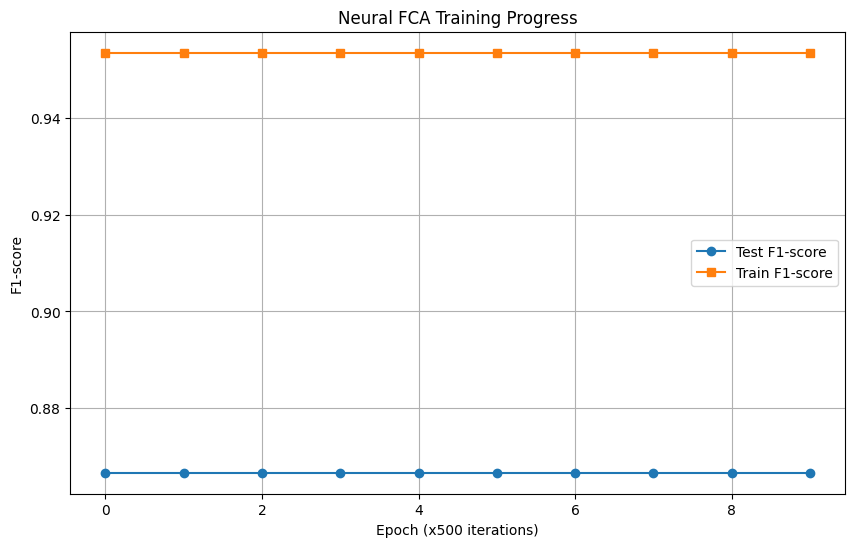

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(f1_list_test, label='Test F1-score', marker='o')
plt.plot(f1_list_train, label='Train F1-score', marker='s')
plt.xlabel('Epoch (x500 iterations)')
plt.ylabel('F1-score')
plt.title('Neural FCA Training Progress')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Add Neural FCA to results
neural_fca_result = [
    'Neural FCA (improved)',
    accuracy_score(y_test_int, pred_test),
    f1_score(y_test_int, pred_test)
]

all_results = results + [neural_fca_result]
all_results_df = pd.DataFrame(all_results, columns=["Model", "Accuracy", "F1-score"])

print("\nFINAL COMPARISON (ALL MODELS)")
print("="*60)
print(all_results_df.sort_values(by="F1-score", ascending=False).to_string(index=False))
print("="*60)


FINAL COMPARISON (ALL MODELS)
                Model  Accuracy  F1-score
Neural FCA (improved)  0.957447  0.866667
  Logistic Regression  0.957447  0.857143
                  SVM  0.957447  0.857143
        Random Forest  0.946809  0.800000
        Decision Tree  0.936170  0.769231
                  kNN  0.925532  0.720000
          Naive Bayes  0.585106  0.360656


Please, modify the ``pos`` dictionary parameter manually. You can obtain the default ``pos`` via Mover.initialize_pos(...) function.

The problematic edges and nodes (in the form of {edge: overlapped nodes indexes}) are:
{(86, 90): frozenset({88, 84})}


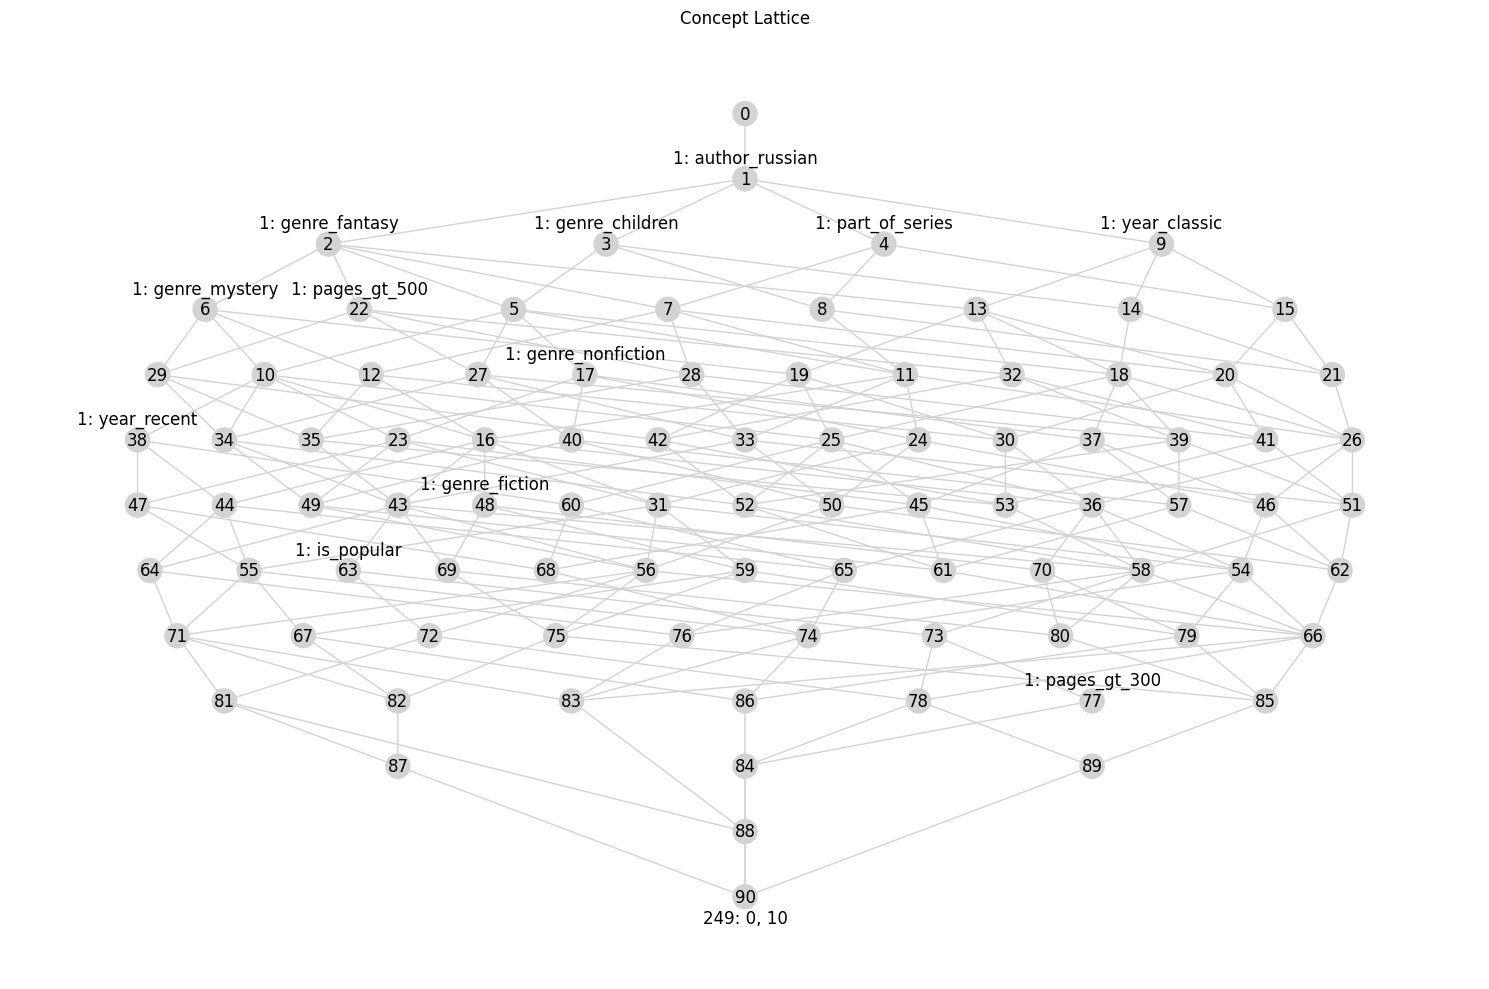

In [36]:
from fcapy.visualizer import LineVizNx

fig, ax = plt.subplots(figsize=(15, 10))
vis = LineVizNx()
vis.draw_concept_lattice(L, ax=ax, flg_node_indices=True)
ax.set_title('Concept Lattice')
plt.tight_layout()
plt.show()

/Users/mochalovskiy/hse/osda/big homework/.venv/lib/python3.10/site-packages/sparselinear/sparselinear.py:301: UserWarning: torch.sparse.SparseTensor(indices, values, shape, *, device=) is deprecated.  Please use torch.sparse_coo_tensor(indices, values, shape, dtype=, device=). (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/utils/tensor_new.cpp:653.)
  weight = torch.sparse.FloatTensor(self.indices, self.weights, (self.out_features, self.in_features))


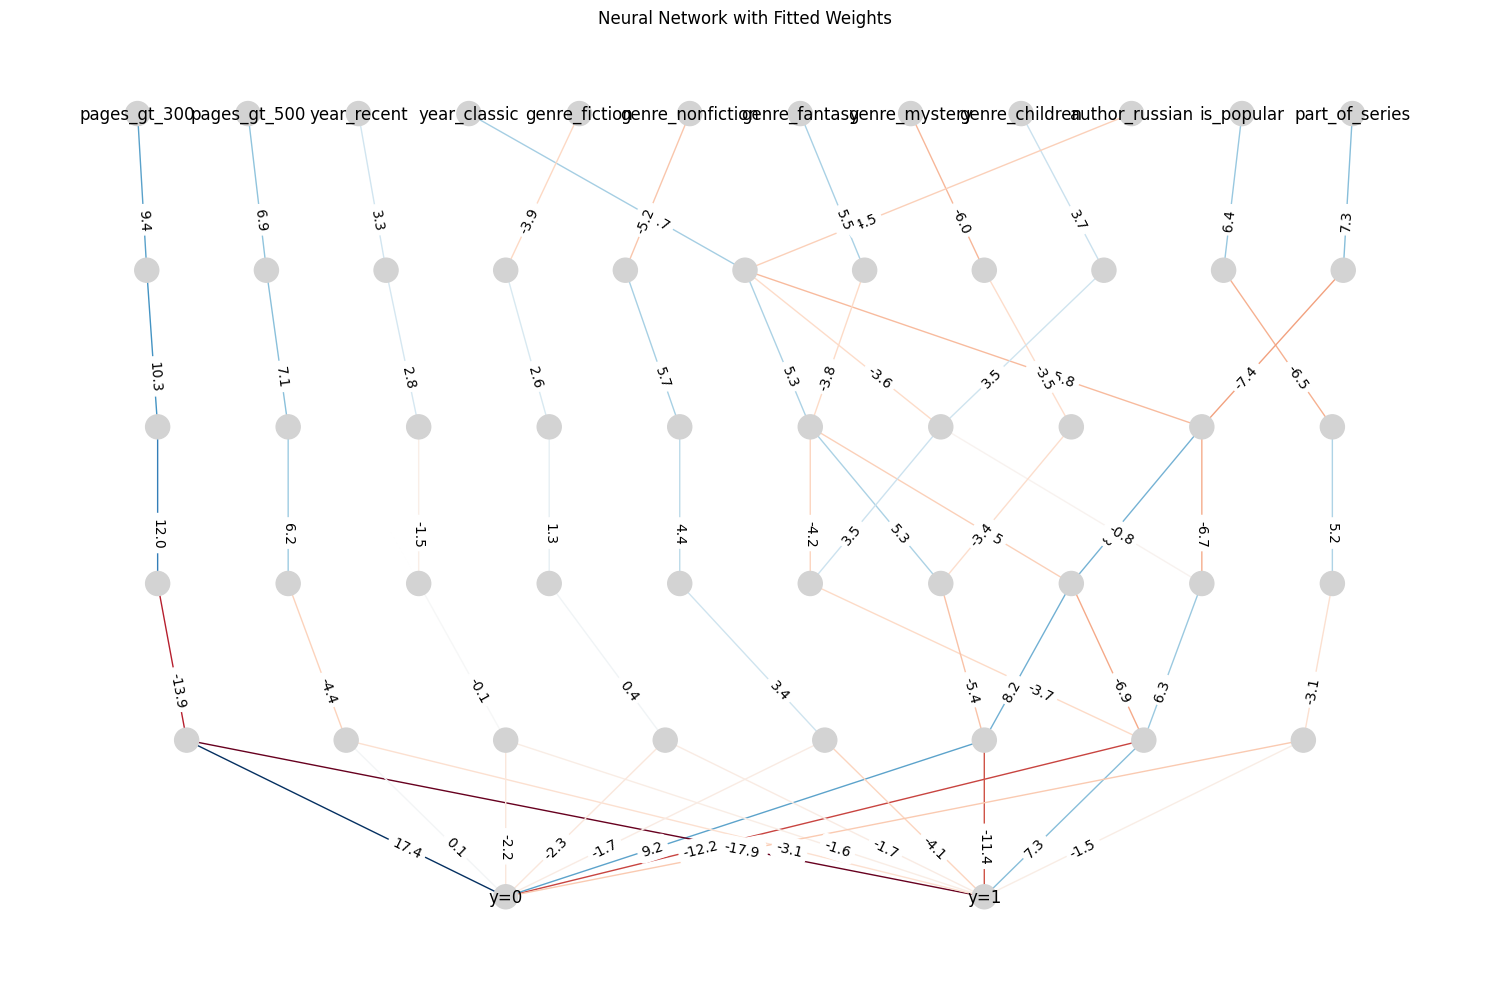

In [37]:
import networkx as nx

edge_weights = cn.edge_weights_from_network()

fig, ax = plt.subplots(figsize=(15, 10))
vis = LineVizNx(
    node_label_func=lambda el_i, P: nl.neuron_label_func(
        el_i, P, set(cn.attributes), only_new_attrs=True
    )
)

vis.draw_poset(
    cn.poset, ax=ax,
    flg_node_indices=False,
    edge_color=[edge_weights[e] for e in cn.poset.to_networkx().edges],
    edge_cmap=plt.cm.RdBu,
)

nx.draw_networkx_edge_labels(
    cn.poset.to_networkx(), vis.mover.pos,
    {k: f"{v:.1f}" for k, v in edge_weights.items()},
    label_pos=0.7
)

plt.title('Neural Network with Fitted Weights')
plt.tight_layout()
plt.show()

In [38]:
print("Best concepts analysis:")
for i, idx in enumerate(best_concepts):
    concept = L[idx][0]
    print(f"\n{i+1}. Concept {idx}:")
    print(f"   Intent: {concept.intent}")
    print(f"   Extent size: {len(concept.extent_i)}")
    print(f"   F1-score: {concept.measures['f1_score']:.3f}")

Best concepts analysis:

1. Concept 15:
   Intent: ('year_classic', 'author_russian', 'part_of_series')
   Extent size: 66
   F1-score: 0.766

2. Concept 9:
   Intent: ('year_classic', 'author_russian')
   Extent size: 47
   F1-score: 0.750

3. Concept 20:
   Intent: ('year_classic', 'genre_fantasy', 'author_russian', 'part_of_series')
   Extent size: 79
   F1-score: 0.683

4. Concept 21:
   Intent: ('year_classic', 'genre_children', 'author_russian', 'part_of_series')
   Extent size: 81
   F1-score: 0.672

5. Concept 13:
   Intent: ('year_classic', 'genre_fantasy', 'author_russian')
   Extent size: 60
   F1-score: 0.653

6. Concept 14:
   Intent: ('year_classic', 'genre_children', 'author_russian')
   Extent size: 62
   F1-score: 0.641

7. Concept 26:
   Intent: ('year_classic', 'genre_fantasy', 'genre_children', 'author_russian', 'part_of_series')
   Extent size: 93
   F1-score: 0.612

8. Concept 30:
   Intent: ('year_classic', 'genre_fantasy', 'genre_mystery', 'author_russian', 'par